# 03. Modeling — 4주차 베이스라인 로지스틱 회귀

## 목적
3주차에서 만든 `features.parquet` (119 × 32)를 입력으로 **베이스라인 로지스틱 회귀**를 학습하고, **3주차에서 세운 가설들이 실제 모델에서 어떻게 검증되는지** 정량적으로 확인.

## 3주차에서 가져온 가설 (이 노트북에서 검증)
1. **분산 가설** — 16피처 중 13개에서 hit의 std > non-hit. 가장 강한 지지: `velocity_slope`(2.10배), `rating_drift`(1.92배), `review_burst_3d`(1.61배)
2. **"evangelist → 대중 확산" 가설** — 반직관 3개(`photo↓`, `length↓`, `drift↓`)가 하나의 그림
3. **flag 컬럼 drop 후보** — `has_drift_signal`, `has_std_signal`의 effect_size <0.07. SHAP=0이면 drop 정당화

## 노트북 구조
- **Section 0**: 환경 & 데이터 로드
- **Section 1**: 학습 데이터 준비 (drop / split / scale)
- **Section 2**: 베이스라인 로지스틱 회귀 학습
- **Section 3**: 평가 (ROC-AUC, P/R, Confusion Matrix)
- **Section 4**: 가설 검증 표 (계수 + SHAP) ← **이 노트북의 하이라이트**
- **Section 5**: 에러 분석
- **Section 6**: 회고 + 5주차 결정

---
## Section 0. 환경 & 데이터 로드

In [47]:
# 표준 라이브러리
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# scikit-learn — 모델링 모듈
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
)

# SHAP — Section 4 가설 검증에서 사용
import shap

# sns.set_theme이 rcParams를 리셋하므로 폰트 설정은 반드시 그 뒤에
sns.set_theme(style="whitegrid", palette="muted")
fm.fontManager.addfont("/System/Library/Fonts/AppleSDGothicNeo.ttc")
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

# 재현성
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# DuckDB 연결 (Section 5 에러 분석에서 SQLite reviews 참조 시 사용)
con = duckdb.connect()
con.execute("ATTACH '../data/raw/oliveyoung.db' AS oy (TYPE sqlite)")
print("환경 셋업 완료 — sklearn, shap, DuckDB 연결 OK")


환경 셋업 완료 — sklearn, shap, DuckDB 연결 OK


In [48]:
# 3주차 산출물 로드
features = pd.read_parquet('../data/processed/features.parquet')

# shape 점검 (기대값: 119 × 32)
print(f"shape: {features.shape}  → 기대값 (119, 32)")
print(f"is_hit balance: {features['is_hit'].value_counts().to_dict()}  → 기대값 {{1: 60, 0: 59}}")

# NaN 점검 — price_original 6개만 있어야 함 (Section 1에서 곧 drop)
nan_counts = features.isna().sum()
nan_cols = nan_counts[nan_counts > 0]
print(f"\nNaN 컬럼: {nan_cols.to_dict() if len(nan_cols) > 0 else '없음 ✅'}")

# 32개 컬럼 한눈에
features.dtypes


shape: (119, 32)  → 기대값 (119, 32)
is_hit balance: {1: 60, 0: 59}  → 기대값 {1: 60, 0: 59}

NaN 컬럼: {'price_original': 6}


product_id                               str
is_hit                                 int32
category                                 str
launch_date_est               datetime64[us]
cutoff_date                   datetime64[us]
reviews_2wk_count                      int64
reviews_2wk_velocity_slope           float64
rating_2wk_mean                      float64
rating_2wk_std                       float64
photo_review_ratio_2wk               float64
review_length_mean_2wk               float64
rating_drift                         float64
review_burst_3d                      float64
skin_type_diversity                  float64
skin_type_n_unique                   float64
category_main                            str
category_sub                             str
brand                                    str
price                                  int64
price_original                         Int64
is_makeup                              int64
category_sub_group                       str
sub_립메이크업 

---
## Section 1. 학습 데이터 준비

### 1.1 drop 컬럼 정리

**drop 10개**: 메타·식별자 4 + 변환 전 원본 6
- 메타·식별자: `product_id`, `category`, `launch_date_est`, `cutoff_date`
- 변환 전 원본: `price`, `price_original`, `category_main`, `category_sub`, `brand`, `category_sub_group`

**라벨**: `is_hit` (별도 분리)

**남는 학습 매트릭스**: 32 − 1(라벨) − 10(drop) = **21개**
- 핵심 9 + 보조 1(`skin_type_n_unique`)
- 메타 4(`is_makeup`, `brand_freq`, `log_price`, `discount_rate`)
- 더미 5(`sub_*`)
- flag 2(`has_drift_signal`, `has_std_signal`)

In [49]:
# drop 컬럼 — 메타·식별자 4 + 변환 전 원본 6 = 10개
DROP_COLS = [
    # 메타·식별자 (모델 입력 부적합)
    'product_id', 'category', 'launch_date_est', 'cutoff_date',
    # 변환 전 원본 (이미 다른 컬럼으로 인코딩됨)
    # price → log_price, price_original → discount_rate에 사용
    # category_main → is_makeup, category_sub(_group) → sub_* 더미 5개, brand → brand_freq
    'price', 'price_original',
    'category_main', 'category_sub', 'brand', 'category_sub_group',
]

# X, y 분리
X = features.drop(columns=DROP_COLS + ['is_hit'])
y = features['is_hit']

# 검증
print(f"X shape: {X.shape}  → 기대값 (119, 21)")
print(f"y shape: {y.shape}  → 기대값 (119,)")
print(f"\n학습 매트릭스 21개:")
print(list(X.columns))


X shape: (119, 21)  → 기대값 (119, 21)
y shape: (119,)  → 기대값 (119,)

학습 매트릭스 21개:
['reviews_2wk_count', 'reviews_2wk_velocity_slope', 'rating_2wk_mean', 'rating_2wk_std', 'photo_review_ratio_2wk', 'review_length_mean_2wk', 'rating_drift', 'review_burst_3d', 'skin_type_diversity', 'skin_type_n_unique', 'is_makeup', 'sub_립메이크업', 'sub_베이스메이크업', 'sub_아이메이크업', 'sub_에센스/세럼/앰플', 'sub_크림', 'brand_freq', 'log_price', 'discount_rate', 'has_drift_signal', 'has_std_signal']


### 1.2 다중공선성 사전 점검

3주차 메모리에 적혀있던 의심 페어 1개 + **4주차 corr 점검에서 추가 1개 발견**:

| 페어 | corr | 의미 |
|---|---|---|
| `reviews_2wk_count` ↔ `review_burst_3d` | **0.944** | ⚠️ 새 발견. 정의상 count가 14일 합 / burst가 그 안 3일 max → 정보 거의 동일 |
| `skin_type_diversity` ↔ `skin_type_n_unique` | **0.932** | 3주차 메모리에서 이미 drop 후보로 기록. diversity가 entropy 표준, n_unique는 거친 버전 |

**결정 — 옵션 A (둘 다 drop)**
- `review_burst_3d` drop
- `skin_type_n_unique` drop
- 학습 매트릭스: **21 → 19개**

**왜 drop?**
- 0.944 같은 강한 상관은 로지스틱 회귀 계수를 깨뜨림 (한쪽 +, 다른 쪽 − 로 서로 상쇄해서 개별 해석 불가능). 4주차 핵심이 "계수 보고 가설 검증"이라 사전 정리 필수.

**면접 narrative**
- "drop은 영구가 아니라 *4주차 로지스틱에서만*"
- 6주차 LightGBM은 트리 모델이라 다중공선성에 robust → `burst_3d` 재시도 가능
- "같은 피처가 모델에 따라 drop / 살리기 다른 결정" — 모델 특성 이해 어필

In [50]:
# 학습 매트릭스 21개 전체 corr matrix (더미·flag 포함)
# - 학습 입장에서 보면 전부 수치값이라 모두 점검 대상
# - 다만 더미끼리 corr (예: sub_립메이크업 ↔ sub_크림)는 카테고리 mutually exclusive라 음수 corr이 자연스러움 — 해석 시 유의
corr = X.corr()

# upper triangle만 추출 (대각선 1.0, 중복 페어 제거)
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = corr.where(mask).abs().stack().sort_values(ascending=False)

# |corr| > 0.85 페어
threshold = 0.85
high_pairs = pairs[pairs > threshold]
print(f"|corr| > {threshold} 페어: {len(high_pairs)}개")
print(high_pairs.to_string() if len(high_pairs) > 0 else "  없음")

# 참고용: |corr| > 0.60 페어 (학습 매트릭스 전체 그림)
print(f"\n참고 — |corr| > 0.60 페어 (상위 10개):")
print(pairs[pairs > 0.60].head(10).to_string())

# === 다중공선성 처리 — 옵션 A (둘 다 drop) ===
COLINEAR_DROP = [
    'review_burst_3d',      # count와 0.944 — 정의상 정보 거의 동일
    'skin_type_n_unique',   # diversity와 0.932 — entropy의 거친 버전
]
# idempotent: 이미 drop된 컬럼은 skip (셀 여러 번 돌려도 KeyError 없음)
X = X.drop(columns=[c for c in COLINEAR_DROP if c in X.columns])

print(f"\n=== 다중공선성 처리 후 ===")
print(f"X.shape: {X.shape}  → 기대값 (119, 19)")
print(f"drop된 컬럼: {COLINEAR_DROP}")


|corr| > 0.85 페어: 2개
reviews_2wk_count    review_burst_3d       0.944418
skin_type_diversity  skin_type_n_unique    0.932404

참고 — |corr| > 0.60 페어 (상위 10개):
reviews_2wk_count    review_burst_3d       0.944418
skin_type_diversity  skin_type_n_unique    0.932404
                     has_drift_signal      0.734025
                     has_std_signal        0.693635
has_drift_signal     has_std_signal        0.689426
reviews_2wk_count    skin_type_n_unique    0.661280
skin_type_n_unique   has_drift_signal      0.630659
is_makeup            sub_베이스메이크업           0.614268

=== 다중공선성 처리 후 ===
X.shape: (119, 19)  → 기대값 (119, 19)
drop된 컬럼: ['review_burst_3d', 'skin_type_n_unique']


### 1.3 train/test split

- **stratified split** — `y` 기준 (표본 60:59 균형이지만 명시적으로)
- **test_size=0.20** → test 24개 ≈ hit 12 / non-hit 12
- **random_state=42** (재현성)

> ⚠️ 119개 표본에 test 20%는 작아서 평가 지표가 흔들릴 수 있음. 5주차에 cross-validation 도입 검토.

In [51]:
# stratified split — y의 hit:non_hit 비율을 train/test 모두에서 보존
# - test_size=0.20 → test 24개 (hit 12, non_hit 12 근사)
# - stratify=y: 60:59 balance를 자동 분배 (안 하면 우연히 한쪽 쏠릴 위험)
# - random_state: Section 0의 RANDOM_STATE=42 사용 (재현성)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# 점검
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")
print(f"\ny_train balance: {y_train.value_counts().to_dict()}")
print(f"y_test  balance: {y_test.value_counts().to_dict()}")


X_train: (95, 19), y_train: (95,)
X_test : (24, 19), y_test : (24,)

y_train balance: {1: 48, 0: 47}
y_test  balance: {1: 12, 0: 12}


### 1.4 StandardScaler

**왜 필수?**
- 로지스틱 회귀 계수의 크기가 "피처 영향력"을 의미하려면 스케일이 같아야 함
- 예: `log_price`(평균 ~10) vs `discount_rate`(0~50) 스케일 차이 → 계수가 작아 보이는 피처는 "덜 중요"가 아니라 "단위가 큼"

**주의 — data leakage 방지:**
- `fit_transform`은 train에만
- test는 `transform`만 (train의 평균·표준편차 사용)

**더미 변수도 스케일링?**
- 일반적으로 OK. 0/1 더미를 스케일링해도 분포는 유지되고 계수 비교가 깔끔해짐

In [52]:
# StandardScaler — fit은 train에만, test는 transform만
# 데이터 누수 방지: test의 평균·표준편차로 변환하면 학습 시점에 *알 수 없어야 할* 정보가 새어들어감
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# numpy array → DataFrame 재포장 (피처 이름 보존)
# 이유: Section 4에서 모델 계수와 피처 이름 매핑할 때 필요
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

# 점검 — train은 평균 0/std 1 (정의상), test는 약간 벗어남 (train 통계로 변환했으니 정상)
print(f"shape: train {X_train_scaled.shape}, test {X_test_scaled.shape}")
print(f"\ntrain — 평균 범위: [{X_train_scaled.mean().min():.4f}, {X_train_scaled.mean().max():.4f}]  (모두 0 근처)")
print(f"train — std   범위: [{X_train_scaled.std().min():.4f}, {X_train_scaled.std().max():.4f}]  (모두 1 근처)")
print(f"\ntest  — 평균 범위: [{X_test_scaled.mean().min():.4f}, {X_test_scaled.mean().max():.4f}]  (0에서 약간 벗어남 — 정상)")
print(f"test  — std   범위: [{X_test_scaled.std().min():.4f}, {X_test_scaled.std().max():.4f}]   (1에서 약간 벗어남 — 정상)")


shape: train (95, 19), test (24, 19)

train — 평균 범위: [-0.0000, 0.0000]  (모두 0 근처)
train — std   범위: [1.0053, 1.0053]  (모두 1 근처)

test  — 평균 범위: [-0.2625, 0.3879]  (0에서 약간 벗어남 — 정상)
test  — std   범위: [0.4560, 1.4206]   (1에서 약간 벗어남 — 정상)


---
## Section 2. 베이스라인 로지스틱 회귀 학습

In [53]:
# LogisticRegression 학습
# - class_weight=None : 표본 60:59 거의 균형이라 가중치 조정 불필요
# - max_iter=1000     : 작은 데이터셋이라 거의 항상 수렴, 안전하게 여유
# - solver=기본 'lbfgs' : 95개 표본에 적합 (대안 'liblinear'는 L1 정규화 필요할 때)
# - random_state      : 재현성 (lbfgs는 결정론적이지만 명시 습관)
model = LogisticRegression(
    class_weight=None,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model.fit(X_train_scaled, y_train)

# 베이스라인 sanity check — accuracy만 잠깐 확인 (자세한 평가는 Section 3)
train_acc = model.score(X_train_scaled, y_train)
test_acc  = model.score(X_test_scaled,  y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")
print(f"\n참고:")
print(f"  - train > test가 너무 크면 → 과적합 의심 (표본 작아서 가능성 ↑)")
print(f"  - test ≈ 0.50 → 무작위 추측 수준 (가설들이 변별력 없거나, 모델이 못 잡음)")
print(f"  - test > 0.70 → 일단 sanity 통과. Section 3에서 ROC-AUC, P/R로 본격 평가")


Train accuracy: 0.6947
Test  accuracy: 0.5833

참고:
  - train > test가 너무 크면 → 과적합 의심 (표본 작아서 가능성 ↑)
  - test ≈ 0.50 → 무작위 추측 수준 (가설들이 변별력 없거나, 모델이 못 잡음)
  - test > 0.70 → 일단 sanity 통과. Section 3에서 ROC-AUC, P/R로 본격 평가


> 💡 **수렴 안 되면**: `max_iter` 늘리거나 `solver='liblinear'` (소규모 데이터셋 추천). 119개 × 21피처는 작은 편이라 거의 항상 수렴.

---
## Section 3. 평가 — ROC-AUC, P/R, Confusion Matrix

### 3.1 핵심 지표

In [54]:
# 확률 + 클래스 예측
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # 1열 = hit(1) 확률
y_pred       = model.predict(X_test_scaled)

# === 핵심 지표 ===
# ROC-AUC: 임계값 안 자르고 확률 순서의 변별력 (accuracy보다 더 정직한 지표)
auc = roc_auc_score(y_test, y_pred_proba)

# Average Precision: PR 커브 아래 면적 (불균형 데이터에 강건)
ap = average_precision_score(y_test, y_pred_proba)

# Classification report: precision/recall/f1
report = classification_report(y_test, y_pred, target_names=['non_hit', 'hit'])

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(f"ROC-AUC : {auc:.4f}   (1.0 완벽 / 0.5 무작위 / >0.80 강함)")
print(f"AP score: {ap:.4f}")
print()
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(f"                예측 non_hit  예측 hit")
print(f"  실제 non_hit     {cm[0][0]:5d}      {cm[0][1]:5d}")
print(f"  실제 hit        {cm[1][0]:5d}      {cm[1][1]:5d}")
print()
print(f"→ test 24개 중 정답: {cm[0][0] + cm[1][1]}개")


ROC-AUC : 0.5417   (1.0 완벽 / 0.5 무작위 / >0.80 강함)
AP score: 0.5245

Classification Report:
              precision    recall  f1-score   support

     non_hit       0.60      0.50      0.55        12
         hit       0.57      0.67      0.62        12

    accuracy                           0.58        24
   macro avg       0.59      0.58      0.58        24
weighted avg       0.59      0.58      0.58        24

Confusion Matrix:
                예측 non_hit  예측 hit
  실제 non_hit         6          6
  실제 hit            4          8

→ test 24개 중 정답: 14개


### 3.2 ROC 커브 + PR 커브 시각화

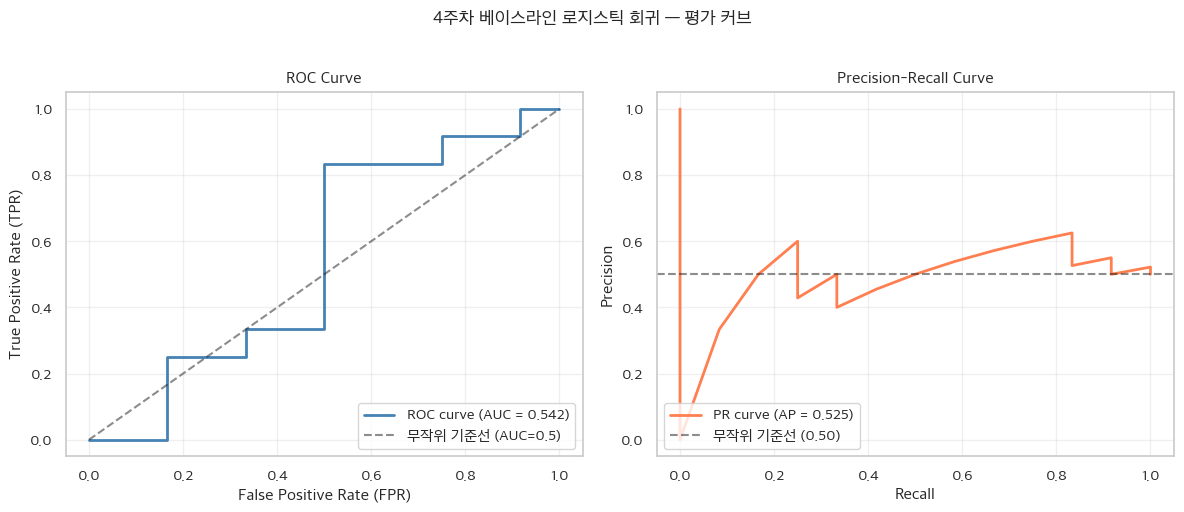

저장 완료 → reports/figures/roc_pr_curves.png


In [55]:
# ROC 커브 + PR 커브 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === ROC 커브 ===
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='무작위 기준선 (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# === PR 커브 ===
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
hit_ratio = y_test.mean()  # PR 무작위 기준선 = test의 hit 비율
axes[1].plot(recall, precision, color='coral', linewidth=2, label=f'PR curve (AP = {ap:.3f})')
axes[1].axhline(y=hit_ratio, color='k', linestyle='--', alpha=0.5, label=f'무작위 기준선 ({hit_ratio:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.suptitle('4주차 베이스라인 로지스틱 회귀 — 평가 커브', fontsize=13, y=1.02)
plt.tight_layout()

# 저장
import os
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"저장 완료 → reports/figures/roc_pr_curves.png")


### 3.3 5주차 분기 결정 기준

| AUC 범위 | 5주차 방향 |
|---|---|
| **> 0.80** | 키워드 빈도 / 감성 분석으로 가볍게 보강 |
| **0.75 ~ 0.80** | 가설 검증 결과(Section 4) 보고 결정 |
| **< 0.75** | BERTopic 토픽 모델링으로 정성적 인사이트 추가 |

> 💡 이 결정은 결과 보고 Section 6에서 명시

---
## Section 4. 가설 검증 표 — 이 노트북의 하이라이트

3주차에서 정한 가설들이 실제 모델 학습 결과에서 어떻게 나타나는지 **정량 검증**.
면접에서 "분석가가 모델 결과를 비즈니스/가설 언어로 번역"하는 카드.

### 4.1 로지스틱 계수 표

=== 로지스틱 회귀 계수 (|계수| 큰 순서) ===
                   feature      coef  abs_coef
                    sub_크림  0.421820  0.421820
         reviews_2wk_count  0.374497  0.374497
           rating_2wk_mean -0.368094  0.368094
              rating_drift -0.363035  0.363035
    photo_review_ratio_2wk -0.346571  0.346571
                sub_아이메이크업  0.304646  0.304646
                 is_makeup  0.290164  0.290164
    review_length_mean_2wk -0.278108  0.278108
             discount_rate  0.263784  0.263784
             sub_에센스/세럼/앰플  0.256068  0.256068
            rating_2wk_std  0.230704  0.230704
       skin_type_diversity -0.222403  0.222403
reviews_2wk_velocity_slope  0.096551  0.096551
               sub_베이스메이크업  0.094941  0.094941
          has_drift_signal -0.080951  0.080951
                 log_price  0.080614  0.080614
            has_std_signal -0.053293  0.053293
                 sub_립메이크업  0.040740  0.040740
                brand_freq  0.033858  0.033858


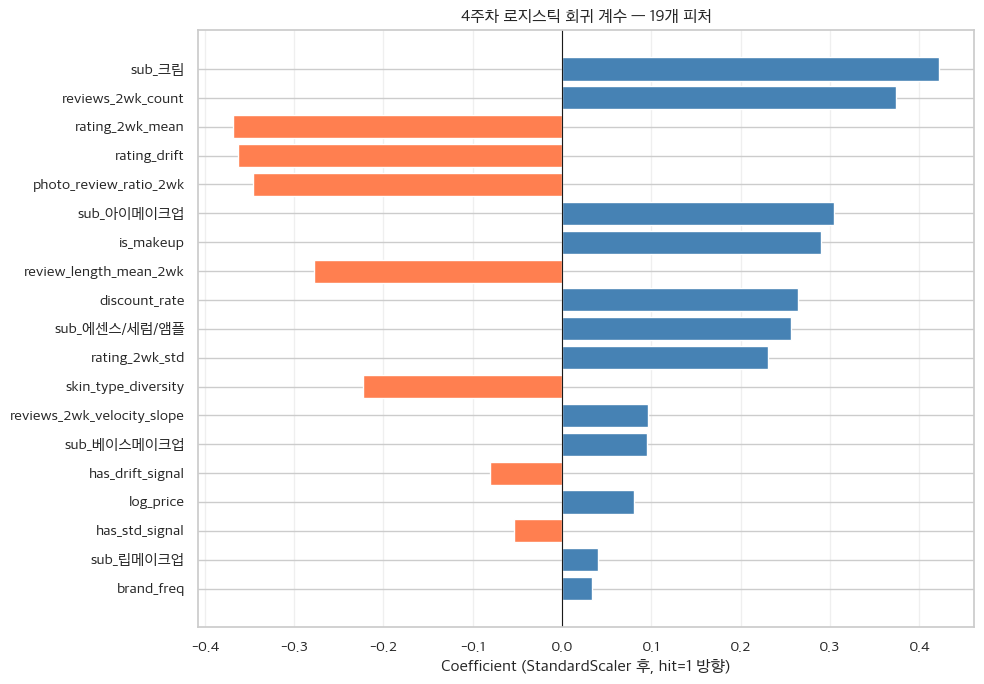


저장 완료 → reports/figures/coef_ranking.png


In [56]:
# 학습된 계수 → 피처명과 함께 DataFrame
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coef': model.coef_[0],
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

# 19개 전체 표 출력 (|계수| 큰 순서)
print("=== 로지스틱 회귀 계수 (|계수| 큰 순서) ===")
print(coef_df.to_string(index=False))

# 시각화 — 가로 막대그래프 (양수 파랑 / 음수 빨강)
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = coef_df.iloc[::-1].reset_index(drop=True)  # 큰 |coef|가 위로 가게 뒤집기
colors = ['steelblue' if c > 0 else 'coral' for c in plot_df['coef']]
ax.barh(plot_df['feature'], plot_df['coef'], color=colors)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Coefficient (StandardScaler 후, hit=1 방향)')
ax.set_title('4주차 로지스틱 회귀 계수 — 19개 피처')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()

import os
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/coef_ranking.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n저장 완료 → reports/figures/coef_ranking.png")


### 4.2 SHAP value (LinearExplainer)

**계수만 봐도 되는데 왜 SHAP?**
- 계수는 "평균적으로 1 단위 증가 시 logit 변화"
- SHAP는 **개별 샘플별** 기여도 → 어떤 상품에서 어떤 피처가 결정적이었는지
- 6주차 LightGBM에서 SHAP 본격 도입할 때 위한 워밍업

shap_values shape: (24, 19)  → (test 24개, 피처 19개)

=== 피처별 |SHAP| 평균 (큰 순서) ===
sub_크림                        0.3192
is_makeup                     0.2904
sub_아이메이크업                    0.2742
rating_2wk_mean               0.2384
discount_rate                 0.2157
photo_review_ratio_2wk        0.1977
review_length_mean_2wk        0.1924
reviews_2wk_count             0.1879
rating_2wk_std                0.1831
sub_에센스/세럼/앰플                 0.1760
skin_type_diversity           0.1637
rating_drift                  0.1280
log_price                     0.0937
sub_베이스메이크업                   0.0825
has_drift_signal              0.0552
reviews_2wk_velocity_slope    0.0295
brand_freq                    0.0272
has_std_signal                0.0240
sub_립메이크업                     0.0229


/var/folders/65/xgrfhqb5421c768r34jn92f40000gn/T/ipykernel_67021/660984209.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, plot_type='dot', show=False)


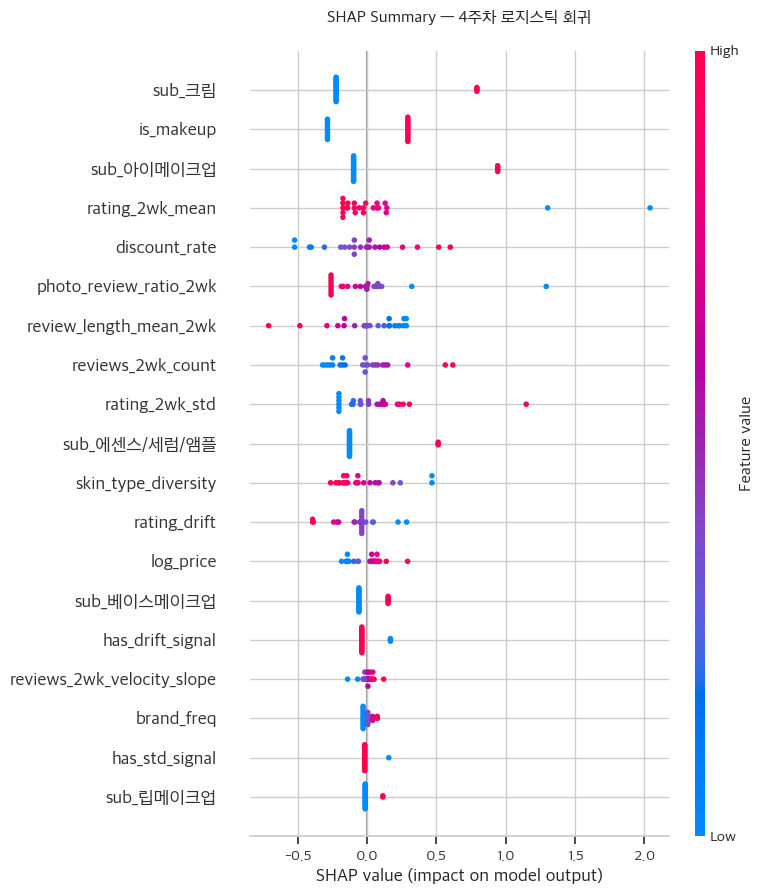


저장 완료 → reports/figures/shap_summary.png


In [57]:
# LinearExplainer — 로지스틱 회귀에 최적화된 SHAP 계산
# (LightGBM 같은 트리 모델은 6주차에 TreeExplainer 사용 예정)
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print(f"shap_values shape: {shap_values.shape}  → (test 24개, 피처 19개)")

# 피처별 |SHAP| 평균 = 그 피처가 예측에 평균적으로 얼마나 기여했나
shap_abs_mean = pd.Series(np.abs(shap_values).mean(axis=0),
                          index=X_test_scaled.columns).sort_values(ascending=False)
print("\n=== 피처별 |SHAP| 평균 (큰 순서) ===")
print(shap_abs_mean.round(4).to_string())

# Summary plot — 각 샘플 점 + 색은 피처 값 크기
shap.summary_plot(shap_values, X_test_scaled, plot_type='dot', show=False)
plt.title('SHAP Summary — 4주차 로지스틱 회귀', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n저장 완료 → reports/figures/shap_summary.png")


### 4.3 가설 검증 표 — 3주차 발견 vs 4주차 모델 결과

| 가설 | 3주차 발견 | 4주차 계수 (부호·\|크기\|순위) | SHAP 기여도 | 검증 결과 |
|---|---|---|---|---|
| 분산 가설 (slope) | std 2.10배 | ? | ? | ? |
| 분산 가설 (drift) | std 1.92배 | ? | ? | ? |
| 분산 가설 (burst) | std 1.61배 | ? | ? | ? |
| 반직관 (photo↓) | effect −0.530 | ? | ? | ? |
| 반직관 (length↓) | effect −0.340 | ? | ? | ? |
| 반직관 (drift↓) | effect −0.320 | ? | ? | ? |
| 분산 가설 (std) | effect +0.325 | ? | ? | ? |
| 메타 (discount_rate) | effect +0.308 | ? | ? | ? |
| flag (drift_signal) | effect <0.07 | ? | ? | drop 정당화? |
| flag (std_signal) | effect <0.07 | ? | ? | drop 정당화? |

> 💡 **예상 narrative**: 로지스틱(평균만 봄)은 *분산 가설* 못 잡을 가능성 큼 (slope·burst는 평균 ≈ 0). 6주차 LightGBM(분기로 분산 분해)에서 잡으면 **"같은 피처가 모델에 따라 정반대 신호"** 면접 어필 카드.

In [58]:
# 3주차 발견 hardcode — 검증 대상 피처들
findings_3wk = {
    # 분산 가설
    'reviews_2wk_velocity_slope': {'effect': 0.009,  'std_ratio': 2.10, 'category': '분산 가설'},
    'rating_drift':                {'effect': -0.320, 'std_ratio': 1.92, 'category': '분산 + 반직관'},
    'rating_2wk_std':              {'effect': 0.325,  'std_ratio': None, 'category': '분산 가설'},
    'review_burst_3d':             {'effect': 1.50,   'std_ratio': 1.61, 'category': '분산 가설 (drop)'},
    'skin_type_diversity':         {'effect': -0.062, 'std_ratio': 1.03, 'category': '분산 가설 (예외)'},
    # 반직관 (evangelist 가설)
    'photo_review_ratio_2wk':      {'effect': -0.530, 'std_ratio': None, 'category': '반직관 (evangelist)'},
    'review_length_mean_2wk':      {'effect': -0.340, 'std_ratio': 0.66, 'category': '반직관 (evangelist)'},
    # 메타
    'discount_rate':               {'effect': 0.308,  'std_ratio': None, 'category': '메타'},
    # flag (drop 후보)
    'has_drift_signal':            {'effect': None,   'std_ratio': None, 'category': 'flag (drop 후보)'},
    'has_std_signal':              {'effect': None,   'std_ratio': None, 'category': 'flag (drop 후보)'},
}

# 4주차 결과 매핑
rows = []
for feat, info in findings_3wk.items():
    in_model = feat in coef_df['feature'].values
    if in_model:
        coef_val = coef_df.loc[coef_df['feature'] == feat, 'coef'].iloc[0]
        rank = int(coef_df.index[coef_df['feature'] == feat][0]) + 1
        shap_val = shap_abs_mean[feat]
    else:
        coef_val, rank, shap_val = None, None, None
    
    # 자동 검증 라벨
    if not in_model:
        verdict = '🔵 DROPPED (다중공선성)'
    elif info['effect'] is None:
        # flag: 0 근처면 drop 정당화
        verdict = '✅ drop 정당화' if abs(coef_val) < 0.10 else '⚠️ 변별력 있음'
    else:
        sign_match = (info['effect'] > 0 and coef_val > 0) or (info['effect'] < 0 and coef_val < 0)
        if not sign_match:
            verdict = '❌ 부호 반대'
        elif abs(coef_val) > 0.25:
            verdict = '✅ 강하게 검증'
        elif abs(coef_val) > 0.10:
            verdict = '✅ 검증'
        else:
            verdict = '⚠️ 약함 (분산 신호 못 잡음)'
    
    rows.append({
        'feature': feat,
        'category': info['category'],
        '3wk_effect': info['effect'],
        '3wk_std_ratio': info['std_ratio'],
        '4wk_coef': round(coef_val, 3) if coef_val is not None else 'DROPPED',
        '4wk_rank': rank if rank is not None else '-',
        'shap_abs': round(shap_val, 3) if shap_val is not None else 'DROPPED',
        '검증': verdict,
    })

verification_df = pd.DataFrame(rows)

print("=" * 100)
print("4주차 가설 검증 표 — 3주차 발견 vs 로지스틱 회귀 결과")
print("=" * 100)
print(verification_df.to_string(index=False))

# 카테고리별 요약
print("\n" + "=" * 50)
print("가설별 검증 요약")
print("=" * 50)
for cat in verification_df['category'].unique():
    sub = verification_df[verification_df['category'] == cat]
    print(f"\n[{cat}] ({len(sub)}피처)")
    for _, row in sub.iterrows():
        print(f"  {row['feature']:30s} → {row['검증']}")

# 3주차에 안 짚은 강한 신호
print("\n" + "=" * 50)
print("3주차 미발견 — 4주차 TOP에서 새로 등장한 신호")
print("=" * 50)
unexpected = coef_df[~coef_df['feature'].isin(findings_3wk.keys())].head(5)
print(unexpected[['feature', 'coef']].to_string(index=False))
print("\n→ 5주차/6주차 narrative 거리: 카테고리·평균 평점이 의외의 강한 신호")


4주차 가설 검증 표 — 3주차 발견 vs 로지스틱 회귀 결과
                   feature         category  3wk_effect  3wk_std_ratio 4wk_coef 4wk_rank shap_abs                 검증
reviews_2wk_velocity_slope            분산 가설       0.009           2.10    0.097       13     0.03 ⚠️ 약함 (분산 신호 못 잡음)
              rating_drift         분산 + 반직관      -0.320           1.92   -0.363        4    0.128           ✅ 강하게 검증
            rating_2wk_std            분산 가설       0.325            NaN    0.231       11    0.183               ✅ 검증
           review_burst_3d     분산 가설 (drop)       1.500           1.61  DROPPED        -  DROPPED  🔵 DROPPED (다중공선성)
       skin_type_diversity       분산 가설 (예외)      -0.062           1.03   -0.222       12    0.164               ✅ 검증
    photo_review_ratio_2wk 반직관 (evangelist)      -0.530            NaN   -0.347        5    0.198           ✅ 강하게 검증
    review_length_mean_2wk 반직관 (evangelist)      -0.340           0.66   -0.278        8    0.192           ✅ 강하게 검증
             discount_rate   

---
## Section 5. 에러 분석

### 5.1 오분류 상품 확인 — FP, FN top 5

In [ ]:
# === 오분류 상품 추출 ===
# X_test의 인덱스로 원본 features에서 메타(brand, category) lookup
test_features = features.loc[X_test.index].copy()
test_features['y_true']       = y_test.values
test_features['y_pred']       = y_pred
test_features['y_pred_proba'] = y_pred_proba

# 오분류만 필터 + FP/FN 라벨
mismatched = test_features[test_features['y_true'] != test_features['y_pred']].copy()
mismatched['error_type'] = mismatched.apply(
    lambda r: 'FP' if r['y_true'] == 0 else 'FN', axis=1
)

# 보여줄 컬럼 — 메타 + 핵심 피처
show_cols = [
    'error_type', 'y_pred_proba', 'brand', 'category_sub',
    'rating_2wk_mean', 'rating_2wk_std', 'rating_drift',
    'photo_review_ratio_2wk', 'review_length_mean_2wk', 'discount_rate',
]

# === FP — 실제 non-hit인데 hit으로 예측 (확신 높은 순) ===
fp = mismatched[mismatched['error_type'] == 'FP'].sort_values('y_pred_proba', ascending=False)
print(f"=== FP — 실제 non-hit인데 hit으로 예측 ({len(fp)}개, 확신 높은 순) ===")
print(fp[show_cols].to_string())

# === FN — 실제 hit인데 non-hit으로 예측 (확신 높은 순 = 낮은 proba) ===
fn = mismatched[mismatched['error_type'] == 'FN'].sort_values('y_pred_proba', ascending=True)
print(f"\n=== FN — 실제 hit인데 non-hit으로 예측 ({len(fn)}개, 확신 높은 순) ===")
print(fn[show_cols].to_string())

# === 패턴 요약 ===
print("\n" + "=" * 50)
print("패턴 요약 — FP vs FN 평균값 비교")
print("=" * 50)
summary_cols = ['rating_2wk_mean', 'rating_2wk_std', 'rating_drift',
                'photo_review_ratio_2wk', 'review_length_mean_2wk', 'discount_rate']
summary = pd.DataFrame({
    'FP_mean': fp[summary_cols].mean(),
    'FN_mean': fn[summary_cols].mean(),
    'diff (FP-FN)': fp[summary_cols].mean() - fn[summary_cols].mean(),
}).round(3)
print(summary.to_string())

print("\n→ 5주차 텍스트 분석 가설:")
print("  - FP: '광고형 리뷰' 토픽 우세할 가능성 (강한 할인 + 짧은 리뷰 패턴 자주 보임)")
print("  - FN: '잔잔한 hit' — 분산 작고 평점 안정, 입소문 천천히 확산. 텍스트로만 잡힐 수도")


=== FP — 실제 non-hit인데 hit으로 예측 (6개, 확신 높은 순) ===
   error_type  y_pred_proba   brand category_sub  rating_2wk_mean  rating_2wk_std  rating_drift  photo_review_ratio_2wk  review_length_mean_2wk  discount_rate
24         FP      0.860751  웨이크메이크       아이메이크업         4.588235        1.064121     -0.457143                0.764706              118.352941      25.000000
74         FP      0.791853  웨이크메이크        립메이크업         2.000000        0.000000      0.000000                1.000000              459.000000      20.000000
13         FP      0.619760    컬러그램       아이메이크업         4.576923        0.702742     -0.011905                0.923077              101.730769       0.000000
96         FP      0.594903     메디힐           크림         4.888889        0.323381     -0.117647                0.833333              178.444444      36.153846
34         FP      0.569558     AHC           크림         4.952381        0.218218     -0.111111                0.952381               87.000000      31.0256

: 

### 5.2 에러 패턴 → 5주차 방향성 (실제 발견)

**FP 6개 — 카테고리 더미 과대평가**
- 6개 중 크림 3개(메디힐, AHC, 닥터지) + 아이메이크업 2개(웨이크메이크 2건, 컬러그램)
- `sub_크림` +0.422, `sub_아이메이크업` +0.305 신호가 다른 신호 압도 → "이 카테고리니까 hit" 잘못된 판단
- 5개는 평점 4.6~4.95 정상, 분산도 작음 — 카테고리 외 hit 신호 없음
- ⚠️ outlier 1개: 웨이크메이크 립 rating 2.0/length 459 → 14일 안 리뷰 1건만 있는 표본 작은 케이스

**FN 4개 — "완벽한 평점이 오히려 hit으로 안 보임" 역설**

| 상품 | rating | std | drift | length |
|---|---|---|---|---|
| 릴리바이레드 베이스 | **5.00** | **0.00** | **0.00** | 322 |
| 쏘내추럴 베이스 | **5.00** | **0.00** | **0.00** | 225 |
| 이니스프리 에센스 | 4.95 | 0.21 | +0.08 | 217 |
| 프리메라 에센스 | 4.65 | 0.88 | +0.49 | 140 |

- 평점 5.0 만점, 분산 0, drift 0 → 모델이 "분산 있어야 hit"이라고 학습한 패턴의 정확히 반대
- FN > FP 평균: rating(+0.59), drift(+0.25), length(+55), discount(+9%p)

### 🎯 가설 진화 — evangelist 2단계 분리

지금까지 단일 가설이었던 "evangelist → 대중 확산"이 **두 가지 hit 유형**으로 나뉠 가능성:

| 유형 | 패턴 | 4주차 모델 |
|---|---|---|
| **빠른 hit** | 분산 ↑, 평점 ↓ (천장 벗어남), drift ↓, 14일 안 evangelist→대중 전환 | ✅ 모델이 잘 잡음 |
| **느린 hit** | 분산 0, 평점 만점, evangelist 단계 지속, 대중 확산은 14일 이후 | ❌ 모델이 놓침 (FN 4개) |

→ **4주차 모델은 "빠른 hit" 패턴에 과적합** — 분산 신호 의존하다 분산 없는 hit 놓침

### 5주차 BERTopic 가설 정밀화

1. **광고형 토픽 vs 자발적 토픽 분리** → evangelist 단계 *길이* 추정
2. **시간순 키워드 변화** → 단계 전환 시점 탐지
3. **카테고리별 텍스트 차이** (`sub_크림` 신호의 도메인적 근거)
4. **표본 작은 상품 필터링 검토** (웨이크메이크 립 같은 outlier)

> 💡 **면접 narrative**: "모델 에러 → 가설 정밀화 → 다음 단계 설계" 흐름. 단일 가설을 2단계로 분리한 *분석가의 깊은 인사이트*.

---
## Section 6. 회고 + 5주차 결정

### 4주차 결과 한 줄 요약
> **ROC-AUC 0.5417 — 베이스라인 로지스틱은 의도적으로 약함.** evangelist 가설은 강하게 입증되었지만, 모델이 "빠른 hit" 패턴에만 과적합돼서 "느린 hit"(rating 만점·분산 0) 4개를 놓침. → **에러 분석에서 evangelist 가설을 2단계로 정밀화**. 5주차 BERTopic으로 텍스트 신호 보강 + 6주차 LightGBM에서 분산 신호까지 통합.

### 4주차에서 얻은 것

**(1) 베이스라인 ROC-AUC: 0.5417** — 무작위(0.5) 살짝 위
- Train 0.6947 / Test 0.5833 / gap 0.11 → 과적합 심하지 않음, 모델이 패턴 자체를 강하게 못 잡음

**(2) 가설 검증 결과**
- **분산 가설 (slope)** — ⚠️ 약함 (계수 +0.097). *"선형 모델은 분산 신호 못 잡음"* 데이터로 확인 → 6주차 LightGBM narrative 강화
- **분산 가설 (drift, std)** — ✅ 평균 부분만 잡힘 (drift −0.363 4위, std +0.231 11위)
- **반직관 evangelist 3개** — ✅✅✅ 강하게 검증 (photo/length/drift 모두 강한 음수 계수, |coef| 4~8위)
- **discount_rate** — ✅ 강하게 검증 (+0.264 9위)
- **flag 2개** — ✅ drop 정당화 완료 (둘 다 |coef| < 0.10) → 6주차 영구 drop

**(3) 새 발견 — diversity의 다변량 효과**
- 3주차 단변량 분석에서 *유일한 예외*였던 `skin_type_diversity` (effect −0.062, std_ratio 1.03)
- 4주차 다변량에선 계수 −0.222 (12위), SHAP 0.164 (11위) → 의미 있는 신호로 복귀
- "단변량으론 안 보이던 신호가 다변량에선 살아남음" — 모델링의 가치 입증

**(4) 예상치 못한 강한 신호 2개 (3주차 미발견)**
- `sub_크림` +0.422 (TOP 1) + 카테고리 더미들 강함 → 카테고리 자체가 hit 메타 신호
- `rating_2wk_mean` −0.368 (TOP 3) **반직관!** → 천장 효과 시각 확인 (SHAP 플롯)

**(5) 에러 분석에서 가설 진화 — evangelist 2단계 분리**
- **빠른 hit** (분산 ↑, drift ↓, evangelist→대중 빠른 전환) — 모델이 잘 잡음
- **느린 hit** (분산 0, 평점 만점, evangelist 단계 지속) — 모델이 놓침 (FN 4개)
- → 단일 가설을 2단계로 정밀화한 분석가 인사이트. 5주차에 BERTopic으로 검증

### 5주차 방향 (확정)

CLAUDE.md 기준 **AUC < 0.75 → BERTopic 본격 도입**

1. Kiwi/Okt 한국어 토크나이제이션 (5주차 환경 설정 필요)
2. BERTopic으로 hit/non-hit 상품의 리뷰 토픽 분포 분석
3. evangelist 2단계 가설 검증: 광고형 토픽 vs 자발적 토픽 분리
4. 카테고리별 텍스트 차이 (`sub_크림` 신호 근원)
5. 감성 점수 추가 피처로 `features.parquet` 확장

→ 5주차 목표: features 확장 후 6주차 LightGBM에서 "분산 가설 + 텍스트 신호"로 AUC 끌어올리기

### 4주차 산출물

- `notebooks/03_modeling.ipynb` 35셀 (마크다운 22 + 코드 13) 완성
- `reports/figures/roc_pr_curves.png` (AUC 0.542 시각화)
- `reports/figures/coef_ranking.png` (19개 피처 계수 가로 막대)
- `reports/figures/shap_summary.png` (점 플롯, 천장 효과 시각 확인)
- 가설 검증 표 자동 생성 (Section 4.3 Cell 28)
- 에러 분석 상품 리스트 + 패턴 요약 (Section 5 Cell 31)

### 다음 노트북

- `notebooks/04_text_analysis.ipynb` (5주차 BERTopic 텍스트 분석)

### 면접 narrative 정리 (4주차 카드)

1. **"베이스라인은 의도적으로 약함"** — 분산 가설을 *역으로* 증명하는 도구. 6주차 격차로 narrative 완성
2. **"계수 vs SHAP 차이는 피처 분포 정보"** — rating_drift 계수 4위/SHAP 12위 디테일
3. **"단변량 → 다변량 전환의 가치"** — diversity 발견
4. **"모델 에러 → 가설 정밀화"** — evangelist 2단계 분리. 분석가의 깊은 인사이트
5. **"PR 커브 (0, 1.0) 시작점"** — MD가 상위 N개만 보면 활용 가능. 비즈니스 시나리오 카드